In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("Airbnb_Open_Data.csv")

C:\Users\khedk\AppData\Local\Temp\ipykernel_24732\3424017332.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Airbnb_Open_Data.csv")


In [3]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [5]:
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

## Handling missing values

In [7]:
df['last review'] = pd.to_datetime(df['last review'], errors = 'coerce')

In [8]:
df.fillna({'reviews per month':0, 'last review':df ['last review'].min()}, inplace = True)

In [9]:
# df.dropna(subset=['Name','host id'], inplace= True)
df.drop(['NAME','host id'], axis=1, inplace=True)

In [11]:
df.isnull().sum()

id                                     0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                            0
reviews per month                      0
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules                        52131
license                           102597
dtype: int64

In [12]:
df.drop(['house_rules','license'], axis=1, inplace=True)

In [13]:
df.head()

,id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,...,2020.0,$966,$193,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,...,2007.0,$142,$28,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0
2,1002403,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,...,2005.0,$620,$124,3.0,0.0,2012-07-11,0.00,5.0,1.0,352.0
3,1002755,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,...,2005.0,$368,$74,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0
4,1003689,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,...,2009.0,$204,$41,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0


In [23]:
# Remove $ sign and conver type to float
df['price'] = df['price'].replace('[\$,]',"", regex = True).astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\khedk\AppData\Local\Temp\ipykernel_24732\3174439387.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]',"", regex = True).astype(float)


In [24]:
df['service fee'] = df['service fee'].replace('[\$,]','',regex = True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\khedk\AppData\Local\Temp\ipykernel_24732\1323522110.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['service fee'] = df['service fee'].replace('[\$,]','',regex = True).astype(float)


In [25]:
df.head()

,id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,...,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0
2,1002403,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,...,2005.0,620.0,124.0,3.0,0.0,2012-07-11,0.00,5.0,1.0,352.0
3,1002755,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,...,2005.0,368.0,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0
4,1003689,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,...,2009.0,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0


In [26]:
df.drop_duplicates(inplace=True)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102058 non-null  int64         
 1   host_identity_verified          101769 non-null  object        
 2   host name                       101654 non-null  object        
 3   neighbourhood group             102029 non-null  object        
 4   neighbourhood                   102042 non-null  object        
 5   lat                             102050 non-null  float64       
 6   long                            102050 non-null  float64       
 7   country                         101526 non-null  object        
 8   country code                    101927 non-null  object        
 9   instant_bookable                101953 non-null  object        
 10  cancellation_policy             101982 non-null  object      

## Descriptive Statics

In [32]:
df.describe()

,id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,1.020580e+05,102050.000000,102050.000000,101844.000000,101811.000000,101785.000000,101658.000000,101875.000000,102058,102058.000000,101739.000000,101739.000000,101610.000000
mean,2.918438e+07,40.728097,-73.949652,2012.488090,625.355580,125.039249,8.126640,27.517948,2018-05-15 05:24:57.524936704,1.162233,3.278733,7.936937,141.043992
min,1.001254e+06,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000
25%,1.509286e+07,40.688730,-73.982580,2007.000000,340.000000,68.000000,2.000000,1.000000,2017-07-31 00:00:00,0.090000,2.000000,1.000000,3.000000
50%,2.918438e+07,40.722290,-73.954440,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-05-22 00:00:00,0.480000,3.000000,1.000000,96.000000
75%,4.327590e+07,40.762760,-73.932350,2017.000000,913.000000,183.000000,5.000000,31.000000,2019-07-01 00:00:00,1.710000,4.000000,2.000000,268.000000
max,5.736742e+07,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.627173e+07,0.055852,0.049502,5.765838,331.672649,66.325905,30.616698,49.571744,NaN,1.682184,1.285089,32.266355,135.429156


## Visualization


#### Q.1 What is the distribution of listing prices ?

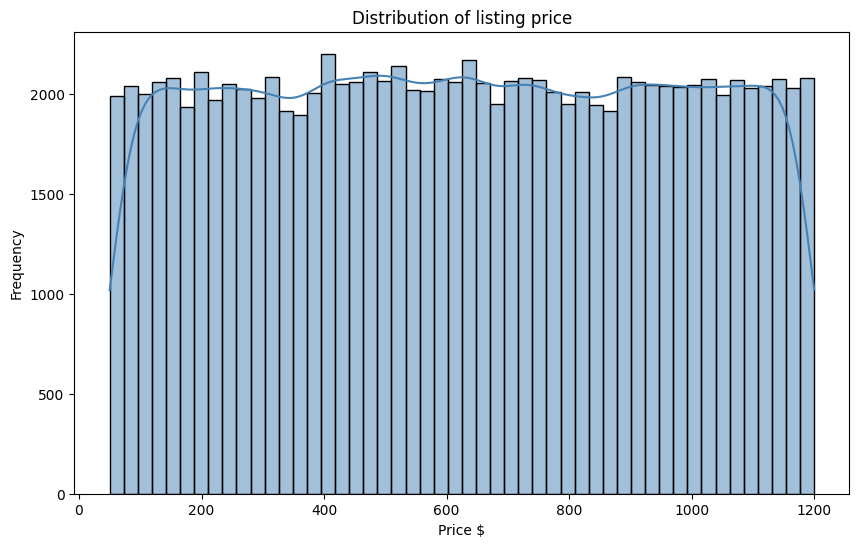

In [44]:
plt.figure(figsize = (10,6))
sns.histplot(df['price'], bins = 50, kde= True, color='Steelblue')
plt.title('Distribution of listing price')
plt.xlabel('Price $')
plt.ylabel('Frequency')
plt.show()

In [ ]:
The histogram shows a fairly even distribution of listing prices across diffrent price ranges,
indicting no perticular concentration of listings in any specific price range.
The KDE line helps visualize this even spread more clearly, confirming that the dataset conatins
listings with a wide variety of prices.

#### Q.2 How are the diffrent room types distributed ?

In [70]:
# df['room type']

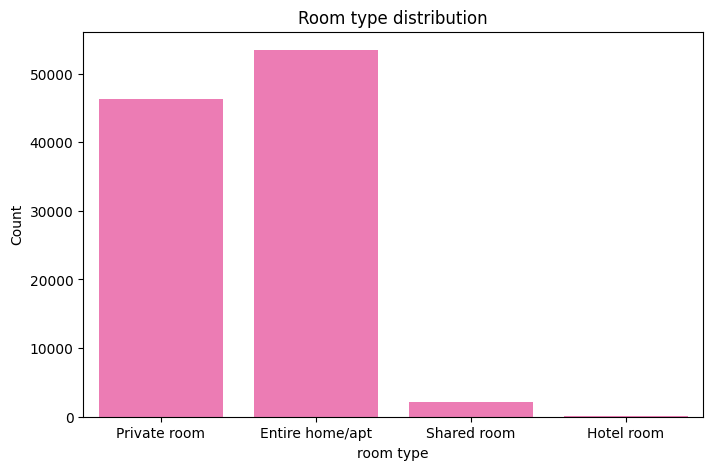

In [59]:
plt.figure(figsize=(8,5))
sns.countplot(x="room type", data=df, color = "hotpink")
plt.title("Room type distribution")
plt.xlabel("room type")
plt.ylabel("Count")
plt.show()

#### Q.3 How are the listing distributed across diffrent neighborhoods?

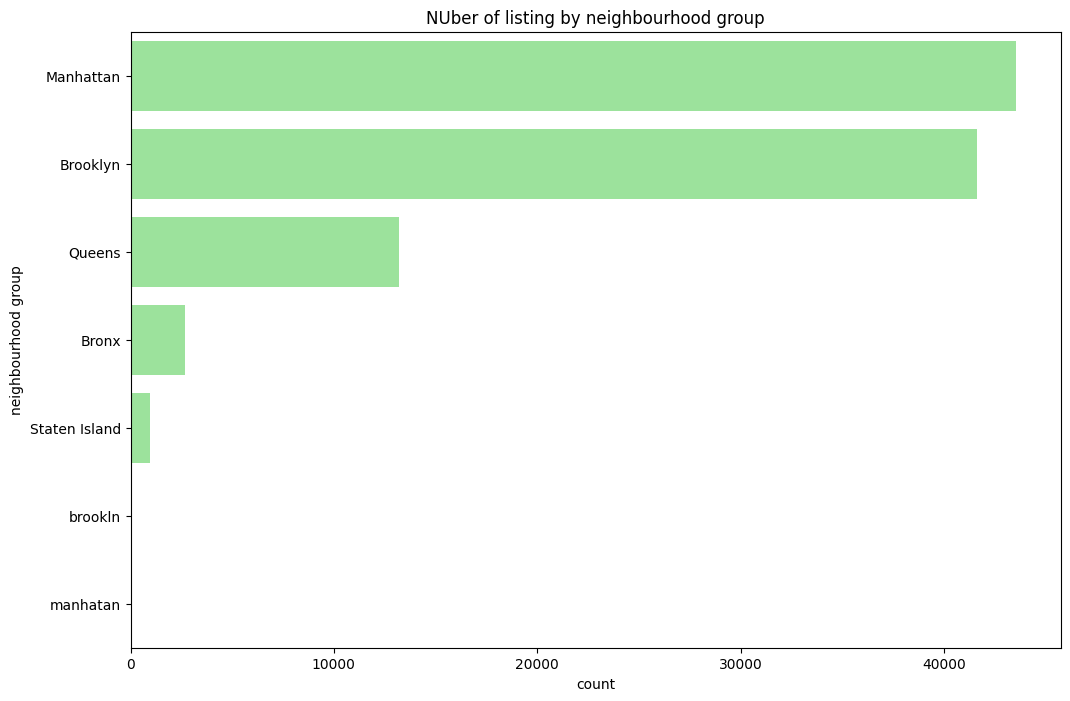

In [63]:
plt.figure(figsize=(12,8))
sns.countplot(y = "neighbourhood group", data = df, color = "lightgreen", order = df["neighbourhood group"].value_counts().index)
plt.title("NUber of listing by neighbourhood group")
plt.xlabel("count")
plt.ylabel("neighbourhood group")
plt.show()

#### Q.4 What is the relationship between price and room type

C:\Users\khedk\AppData\Local\Temp\ipykernel_24732\3874706189.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = "Room Type")


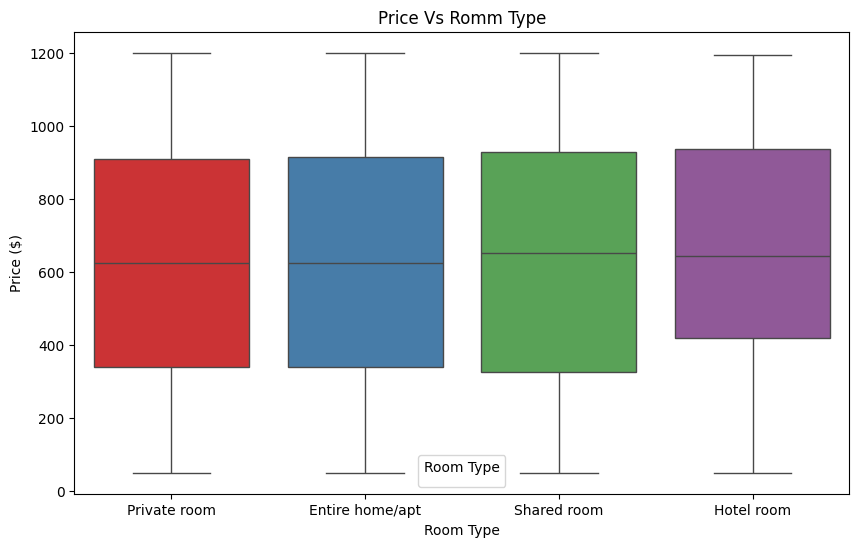

In [65]:
plt.figure(figsize=(10,6))
sns.boxplot(x='room type',y = 'price', hue='room type',data = df, palette = 'Set1')
plt.title("Price Vs Romm Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.legend(title = "Room Type")
plt.show()

#### Q.5 How has the number of reviews chage over time?

In [66]:
df['last review'] = pd.to_datetime(df['last review'])
reviews_over_time = df.groupby(df['last review'].dt.to_period('M')).size()

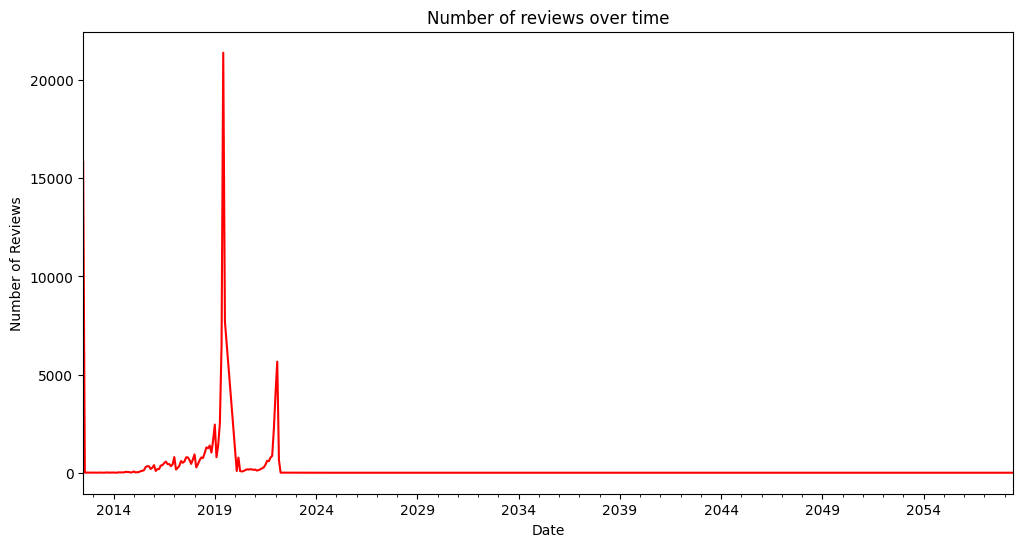

In [69]:
plt.figure(figsize=(12,6))
reviews_over_time.plot(kind = 'line',color='red')
plt.title('Number of reviews over time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()